# Midterm Exam (part 2) - Computational Physics I

### Practice
### Credits: 10 points

### Duration: 1 hour 15 minutes

## Name: Silva Alejandro

### Instructions:

- When you finish, please send me the **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The exam is individual. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems:

## 5. Image processing: identifying sunspots (10 points) 

The purpose of this problem is to isolate and image a sunspot, and then calculate its size.

Sunspots are **dark spots on the Sun's surface that are cooler than the surrounding (brighter) areas due to intense magnetic activity**. They often appear in groups and are indicators of high Solar activity (called Solar maxima, which refer to the periods of peak solar activity during the Sun's 11-year solar cycle). We are currently within a Solar maxima period, which is expected to peak in July 2025. During such periods, sunspots, solar flares, and other solar phenomena are frequent.

### SDO sunspot data: 

The Solar Dynamics Observatory (SDO), launched by NASA in 2010, continuously monitors the Sun, capturing high-resolution images of its atmosphere. Its Atmospheric Imaging Assembly (AIA) provides data in multiple wavelengths, allowing us to study Solar dynamics and sunspot formation. Today's Sun images can be found here: https://suntoday.lmsal.com/suntoday/?suntoday_date=2024-10-18).

Please download the SDO data from: https://github.com/wbandabarragan/physics-teaching-data/tree/main/2D-data/f1700.fits

This file has an image of the Sun at a wavelength of $1700\,\rm Å$, which observes the lower photosphere (i.e. the visible surface of the Sun). It shows the cooler layers of the Sun at temperatures of $5000-6000\,\rm K$). It also highlights bright regions associated with magnetic activity and sunspots, so it is ideal for this exercise.

### Tasks:

### (a) Open the FITS file and inspect its content and structure. You should see a header and the data.

In [1]:
#Import useful libraries
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filename = "/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/f1700.fits"
sun_atm = fits.open(filename)

print(type(sun_atm))
print(len(sun_atm))

<class 'astropy.io.fits.hdu.hdulist.HDUList'>
2


In [3]:
head_sun_atm = sun_atm[0].header

keys_sun_atm = sun_atm[1].header.keys

data_sun_atm = sun_atm[1].data

In [4]:
#print(keys_sun_atm)

In [5]:
print(type(data_sun_atm), data_sun_atm.shape)

<class 'numpy.ndarray'> (4096, 4096)


### (b) Create an I/O python function that reads in the filename and returns the header and the data as objects in a tuple.

In [6]:
def io_sun_atm(filename):
    """
    This function read a .fits file and returns the header and the stored data as objects in a tuple.
    Inputs: filename (path to file, it's a string).
    Outputs: sun_tuple (tuple with the header and the data).
    """
    #Read the file using astropy.io fits
    sun_atm = fits.open(filename)
    
    #Get the header and the data
    head_sun_atm = sun_atm[1].header

    data_sun_atm = sun_atm[1].data

    #Append to tuple
    sun_tuple = (head_sun_atm, data_sun_atm)

    return sun_tuple

In [7]:
#Safe check
sun_atm_tuple = io_sun_atm(filename)

print(type(sun_atm_tuple), type(sun_atm_tuple[1]) )

<class 'tuple'> <class 'numpy.ndarray'>


### (c) Call your I/O function, store the header and data objects, and make a high-quality figure showing the image of the Sun with a colour bar in linear scale. For optimal sunspot visualisation, you will need to fix the limits of the colour bar and choose an adequate colour palette. How many sunspots can you visually spot?

In [8]:
print(sun_atm_tuple[1].shape)

(4096, 4096)


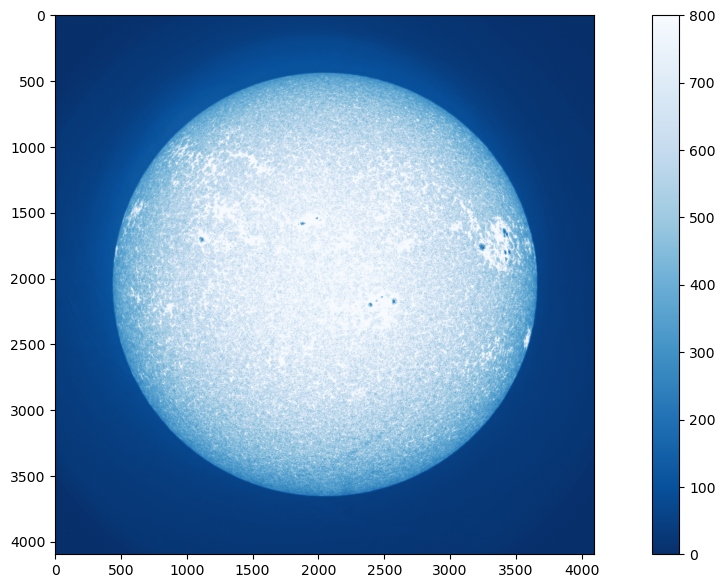

In [9]:
plt.figure(figsize = (15,7))

sun_atm = plt.imshow(sun_atm_tuple[1], cmap = "Blues_r", vmin = 0, vmax = 800)

plt.colorbar(sun_atm)


plt.show()
plt.close()

There are about 14 sunspots.

### (d) Now you need to isolate a single sunspot. Select one target sunspot and use indexing to zoom into it. Make a high-quality figure showing the subset (zoomed-in) image of the Sun, containing your target sunspot.

In [10]:
sun_spot_subset = sun_atm_tuple[1][1700:2050,3000:3350]

print(sun_spot_subset.shape)

(350, 350)


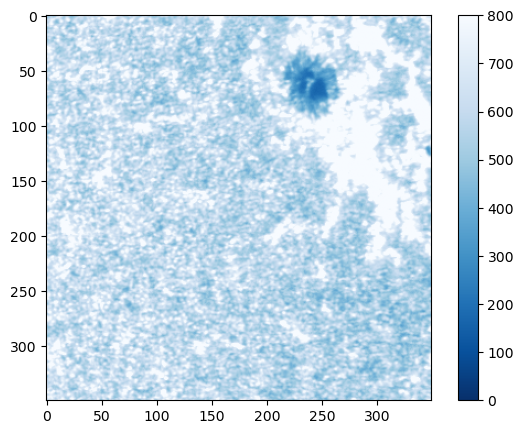

In [11]:
# Plot the resulting image without the background:

# Let's look at the image

fig, ax = plt.subplots(figsize=(7,5))

sun_subset = ax.imshow(sun_spot_subset, cmap = "Blues_r", vmin = 0, vmax = 800)

plt.colorbar(sun_subset)

plt.show()
plt.close()

### (e) Make a 1D histogram of pixel intensity within the subset (zoomed-in) image. Do the sunspots have low or high intensities?

In [12]:
# Reshape arrays into a 1D vector:
sun_atm_1d = np.reshape(sun_spot_subset, (sun_spot_subset.size, 1))

print(sun_atm_1d.shape)

(122500, 1)


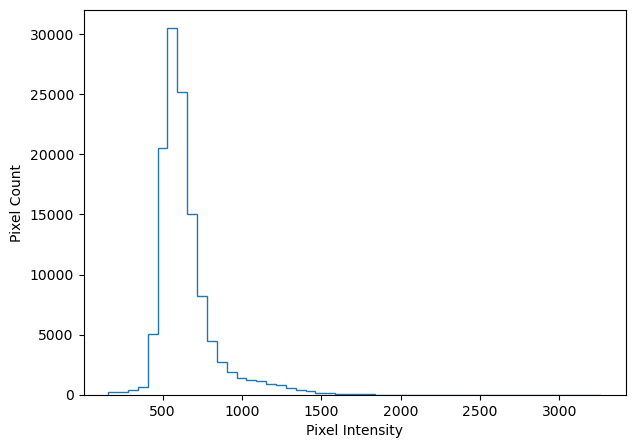

In [13]:
# Histogram plot:

plt.figure(figsize=(7,5))

plt.hist(sun_atm_1d, histtype = "step", bins = 50)


plt.xlabel("Pixel Intensity")
plt.ylabel("Pixel Count")

plt.show()
plt.close()

The sun spots have low-intensity values.

### (f) Create a python function that isolates the area covered by the sunspot. Your function should read the subset image and return a cleaned binary image array with ones in the sunspot and zeroes outside.

In [14]:
def binary_sun_spot(sun_subset):
    """
    This function highlights the area covered by the sunspot by ousing a thresholding algorithm on the pixels itensity of the image.
    The sunspots have low-intensity values.
    """
    #Thresholding
    sun_spot_binary = np.where(sun_subset < 370, 1., 0.)

    return sun_spot_binary

### (g) Call your function and make a high-quality figure showing the binary image of the sunspot with an appropriate colour bar.

In [15]:
sun_spot_binary = binary_sun_spot(sun_spot_subset)

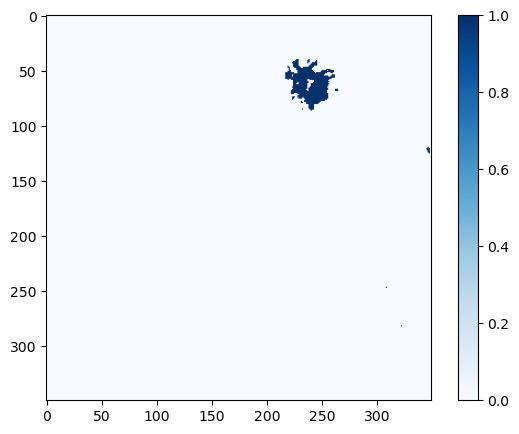

In [16]:
# Plot the resulting image:

fig, ax = plt.subplots(figsize=(7,5))

sun_subset_bin = ax.imshow(sun_spot_binary, cmap = "Blues", vmin = 0, vmax = 1)

plt.colorbar(sun_subset_bin)

plt.show()
plt.close()

### (h) Using your binary image, calculate the total area in pixel units covered by the sunspot, and estimate the sunspot radius also in pixel units assuming that its area is circular, i.e. $A_{\rm sunspot}=\pi\,r_{\rm sunspot}^2$.

In [17]:
a_pix = np.sum(sun_spot_binary)
print(f"The total area in pixels is: {a_pix}")

The total area in pixels is: 1072.0


In [18]:
radius_sun_spot = np.sqrt(a_pix/np.pi) #in pixels
print(f"The radius in pixels is: {radius_sun_spot}")

The radius in pixels is: 18.47236308621676


### (i) Now you need to calculate the sunspot radius in physical units ($\rm km$). To do this, you first need to read from the FITS file the header information on the angular size of a pixel in the image (called "CDELT1" in units of $\rm arcsec$). Use the header object returned in (c) and isolate the value of "CDELT1" from it. Then, convert it to a physical size (in $\rm km$) using the Earth-Sun distance of $1.496\times 10^8\,\rm km$ and trigonometry.

In [19]:
CDELT1 = sun_atm_tuple[0]["CDELT1"]

print(CDELT1)

0.600000024


In [20]:
#Convert from arcsecs to degrees
#1 arcsec = 4.8481e-6 rad
ang_size = CDELT1*4.8481e-6 #in radians

$$
tan(\alpha) = \frac{diameter}{Distance Earth-Sun}
$$

In [22]:
#Earth-Sun distance
dist_ES = 1.496e08 #in km

#Diameter in pixels
diam_pix = 2*radius_sun_spot

#Use trigonometry to find the diameter in km
diameter_km = diam_pix*dist_ES*np.tan(ang_size) #diameter in km

#Get the radius
radius_km = diameter_km/2

print(f"The radius of the sun spot is {radius_km:.3e} [km].")

The radius of the sun spot is 8.039e+03 [km].


### (j) Use the calculated value of "CDELT1" (in $\rm km$) to estimate the sunspot radius in $\rm km$. Based on your results, are sunspots larger or smaller than the Earth? For reference, the Earth radius is $6.37\times 10^3\,\rm km$.

In [23]:
radius_Earth = 6.37e03

print(radius_km > radius_Earth)

True


Some sunspots are larger than the Earth!